Title - Loan Status Prediction Using SVM

1. Importing the libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


2. Adding the dataset

In [64]:
loan = pd.read_csv('dataset/loan.csv')

print("First five rows of the dataset:")
loan.head()

First five rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [65]:
print("Last five rows of the dataset:")
loan.tail()

Last five rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


3. Data Preprocessing

In [66]:
print("\nDataset shape: ", end=" ")
print(loan.shape)
print("\nDataset columns: ", end=" ")
print(loan.columns)
print("\nDataset info:")
loan.info()


Dataset shape:  (614, 13)

Dataset columns:  Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_Hi

In [67]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [68]:
missing_loan=loan.isnull().sum()
print("Missing values in each column:")
print(missing_loan)
print(f"Total missing values in the dataset: {missing_loan.sum()}")

Missing values in each column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Total missing values in the dataset: 149


4. Exploratory Data Analysis

In [69]:
loan.drop(columns=['Loan_ID'], inplace=True)
print("Loan_ID column dropped.")

Loan_ID column dropped.


In [70]:
loan['Gender']           = loan['Gender'].fillna(loan['Gender'].mode()[0])
loan['Married']          = loan['Married'].fillna(loan['Married'].mode()[0])
loan['Dependents']       = loan['Dependents'].fillna(loan['Dependents'].mode()[0])
loan['Self_Employed']    = loan['Self_Employed'].fillna(loan['Self_Employed'].mode()[0])

loan['LoanAmount']       = loan['LoanAmount'].fillna(loan['LoanAmount'].median())
loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].mode()[0])
loan['Credit_History']   = loan['Credit_History'].fillna(loan['Credit_History'].mode()[0])

print("Missing values handled.")
print("Remaining missing values:")
print(loan.isnull().sum())

Missing values handled.
Remaining missing values:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [71]:
loan['Dependents'] = loan['Dependents'].replace('3+', '3').astype(int)
print("Dependents column cleaned:", loan['Dependents'].unique())

Dependents column cleaned: [0 1 2 3]


In [72]:
#Label Encoding for categorical columns

categorical_columns = ['Gender', 'Married', 'Education',
                        'Self_Employed', 'Property_Area', 'Loan_Status']

le = LabelEncoder()

for col in categorical_columns:
    loan[col] = le.fit_transform(loan[col])
    print(f"  {col}: {list(le.classes_)} → {list(range(len(le.classes_)))}")

print("\nEncoding complete!")
loan.head()

  Gender: ['Female', 'Male'] → [0, 1]
  Married: ['No', 'Yes'] → [0, 1]
  Education: ['Graduate', 'Not Graduate'] → [0, 1]
  Self_Employed: ['No', 'Yes'] → [0, 1]
  Property_Area: ['Rural', 'Semiurban', 'Urban'] → [0, 1, 2]
  Loan_Status: ['N', 'Y'] → [0, 1]

Encoding complete!


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


5. Data Visualization

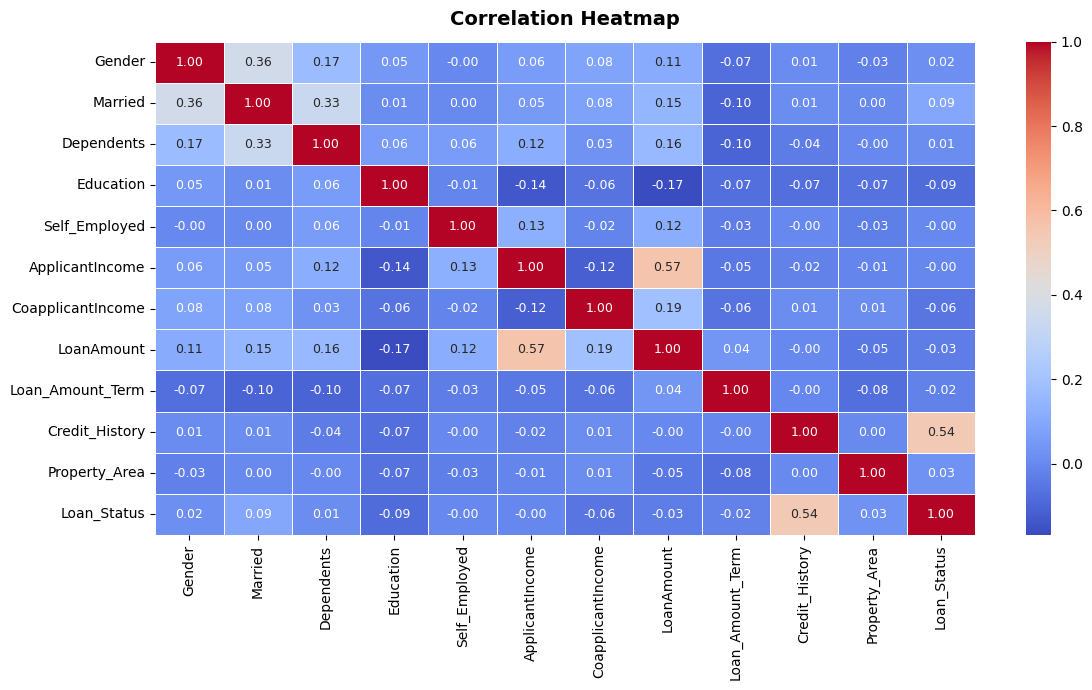

Credit_History shows the strongest correlation with Loan_Status.


In [76]:
plt.figure(figsize=(12, 7))
corr = loan.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', annot_kws={'size': 9})
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Credit_History shows the strongest correlation with Loan_Status.")

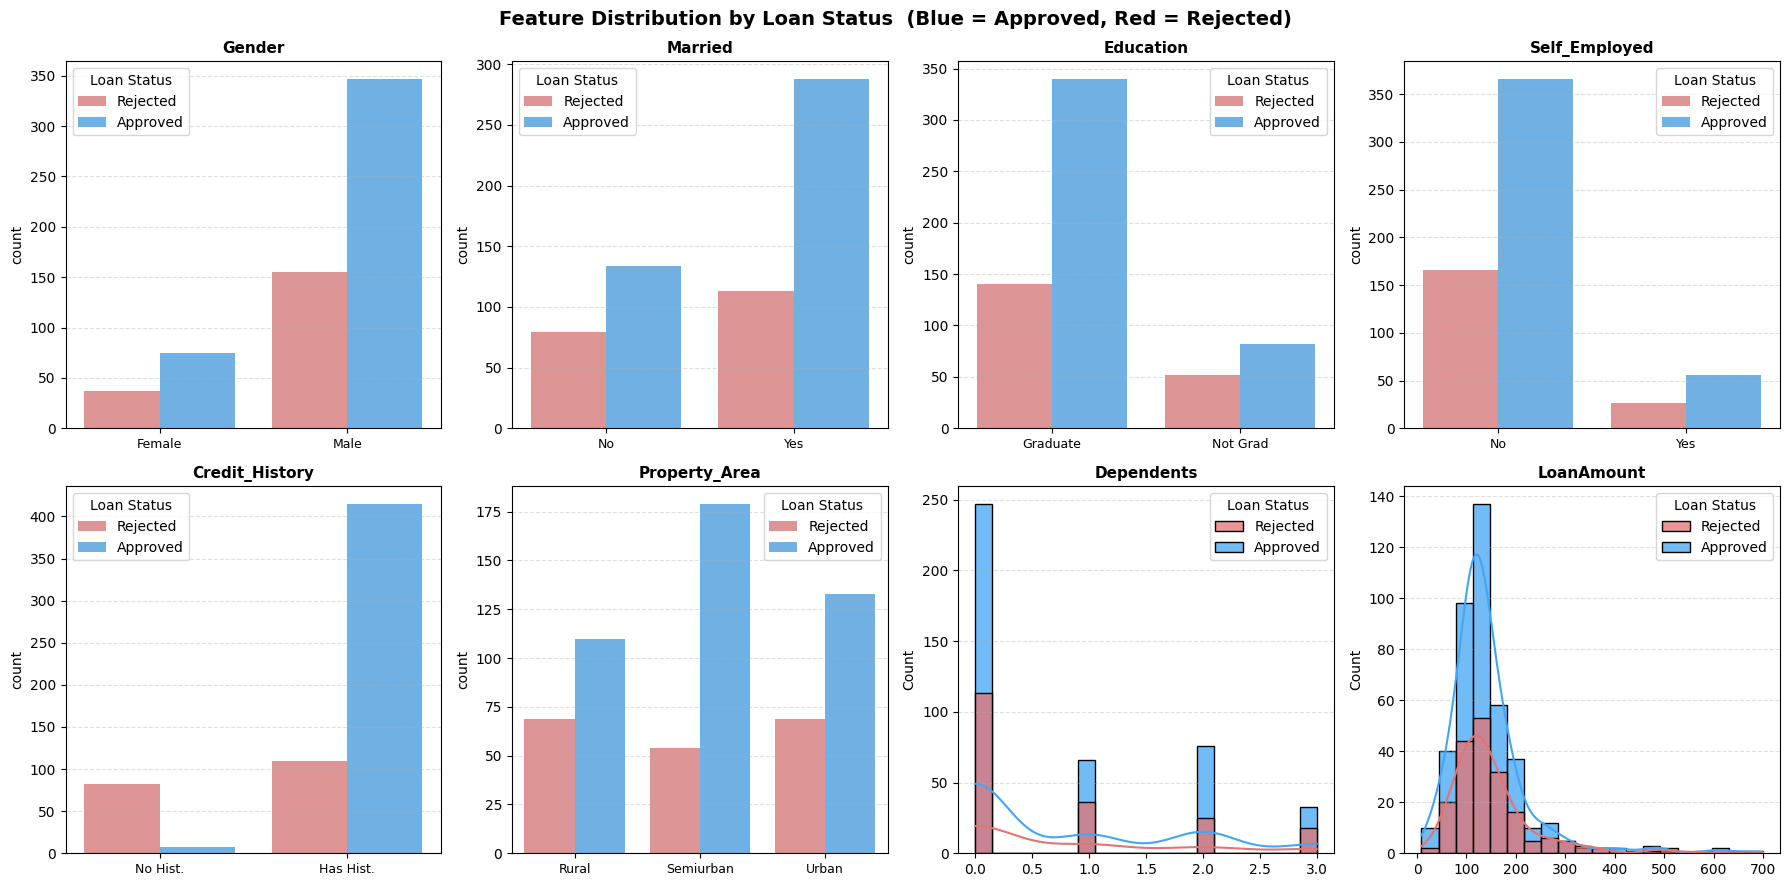

Plot saved to output/feature_distribution.png


In [77]:
palette = {0: '#E57373', 1: '#42A5F5'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Feature Distribution by Loan Status  (Blue = Approved, Red = Rejected)",
             fontsize=14, fontweight='bold')

features  = ['Gender', 'Married', 'Education', 'Self_Employed',
             'Credit_History', 'Property_Area', 'Dependents', 'LoanAmount']
xtick_map = {
    'Gender':        ['Female', 'Male'],
    'Married':       ['No', 'Yes'],
    'Education':     ['Graduate', 'Not Grad'],
    'Self_Employed': ['No', 'Yes'],
    'Credit_History':['No Hist.', 'Has Hist.'],
    'Property_Area': ['Rural', 'Semiurban', 'Urban'],
}

for ax, feat in zip(axes.flat, features):
    if feat in ['LoanAmount', 'Dependents']:
        sns.histplot(data=loan, x=feat, hue='Loan_Status', ax=ax,
                     palette=palette, kde=True, bins=20, alpha=0.75)
    else:
        sns.countplot(data=loan, x=feat, hue='Loan_Status', ax=ax,
                      palette=palette, alpha=0.85)
        if feat in xtick_map:
            ax.set_xticklabels(xtick_map[feat], fontsize=9)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    legend = ax.get_legend()
    if legend:
        legend.set_title('Loan Status')
        for t, lbl in zip(legend.texts, ['Rejected', 'Approved']):
            t.set_text(lbl)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("output/feature_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to output/feature_distribution.png")

6. Train Test Split

In [78]:
X = loan.drop(columns=['Loan_Status'])
y = loan['Loan_Status']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (614, 11)
Target shape:   (614,)

Feature columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep class distribution balanced
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training samples : 491
Test samples     : 123

Train class distribution:
Loan_Status
1    337
0    154
Name: count, dtype: int64

Test class distribution:
Loan_Status
1    85
0    38
Name: count, dtype: int64


7. Feature Scaling

In [80]:
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler (no re-fitting!)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling complete!")
print(f"Train data — Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test  data — Mean: {X_test_scaled.mean():.4f},  Std: {X_test_scaled.std():.4f}")

Feature scaling complete!
Train data — Mean: -0.0000, Std: 1.0000
Test  data — Mean: -0.0303,  Std: 1.0005


8. Train the Model

In [84]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

# Train the model on the scaled training data
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")
print(f"\nModel kernel: {svm_model.kernel}")
print(f"Number of support vectors: {sum(svm_model.n_support_)}")

SVM model trained successfully!

Model kernel: rbf
Number of support vectors: 279


9. Evaluation

In [85]:
X_train_prediction = svm_model.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, y_train)

In [86]:
print('Accuracy on training data : ', training_data_accuracy)

Accuracy on training data :  0.8167006109979633


In [87]:
X_test_prediction = svm_model.predict(X_test_scaled)
test_data_accuracy = accuracy_score(X_test_prediction, y_test)

In [89]:
print('Accuracy on test data : ', test_data_accuracy)

Accuracy on test data :  0.8536585365853658
